# VSC RAVDESS — LoRA Rank 16 Inference Notebook

نوت بوك مستقلة لتشغيل واختبار الموديل:

`vsc_ravdess_lora_r16_test73_24.pt`

## مواصفات النسخة المعتمدة

- **Backbone:** Swin Transformer Tiny
- **LoRA:** Rank 16 — Alpha 32 — عدد 12 طبقة `qkv`
- **Temporal Model:** TCN بقنوات `[256, 256, 256]` وDilations `[1, 2, 4]`
- **Aggregation:** Temporal Attention
- **Input:** عدد 16 فريم، مقاس `224×224`
- **Validation Accuracy:** `73.88%`
- **Test Accuracy:** `73.24%`
- **ترتيب الفئات:**

```python
["neutral", "calm", "happy", "sad",
 "angry", "fearful", "disgust", "surprised"]
```

## ما تحتويه النوت بوك

1. تجهيز بيئة التشغيل.
2. تعريف المعمارية المطابقة للـCheckpoint.
3. تحميل الموديل مع إصلاح تلقائي لتنسيق المفاتيح القديمة.
4. استخراج 16 فريم موزعين على الفيديو.
5. اكتشاف وقص أكبر وجه باستخدام MTCNN.
6. تشغيل التنبؤ على فيديو فردي.
7. عرض احتمالات جميع المشاعر والفريمات التي دخلت الموديل.
8. تشغيل الموديل على مجلد فيديوهات كامل وحفظ النتائج في CSV.

> هذه النوت بوك مخصصة للتشغيل والاستدلال فقط، وليست لإعادة التدريب.


## 1) تجهيز المكتبات

في Kaggle فعّل الـGPU من:

`Settings → Accelerator → GPU`

خلية التثبيت لا تعيد تثبيت PyTorch أو Torchvision، حتى لا يحدث تعارض مع بيئة Kaggle.


In [1]:
# تثبيت MTCNN بدون تغيير PyTorch أو Torchvision
%pip install -q --no-deps facenet-pytorch==2.6.0

print("✅ تم تجهيز المكتبة المطلوبة.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.1 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.
✅ تم تجهيز المكتبة المطلوبة.


## 2) الاستيراد والإعدادات الأساسية

In [2]:
import os
import cv2
import math
import json
import shutil
import tempfile
import warnings

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt

from PIL import Image
from facenet_pytorch import MTCNN
from torchvision import transforms

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch    :", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)
print("Device     :", DEVICE)

if DEVICE.type == "cuda":
    print("GPU        :", torch.cuda.get_device_name(0))

PyTorch    : 2.10.0+cu128
Torchvision: 0.25.0+cu128
Device     : cuda
GPU        : Tesla T4


In [3]:
# ترتيب المخرجات الصحيح لموديل Test 73.24%
MODEL_CLASSES: List[str] = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised",
]

RAVDESS_CODE_TO_EMOTION: Dict[str, str] = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}


@dataclass
class ModelConfig:
    num_frames: int = 16
    image_size: int = 224
    num_classes: int = 8

    swin_feature_dim: int = 768

    tcn_channels: Tuple[int, int, int] = (256, 256, 256)
    tcn_kernel_size: int = 3
    tcn_dropout: float = 0.3

    attention_hidden_dim: int = 128

    lora_rank: int = 16
    lora_alpha: float = 32.0

    face_margin: float = 0.10
    min_face_probability: float = 0.50


CFG = ModelConfig()
print(CFG)

ModelConfig(num_frames=16, image_size=224, num_classes=8, swin_feature_dim=768, tcn_channels=(256, 256, 256), tcn_kernel_size=3, tcn_dropout=0.3, attention_hidden_dim=128, lora_rank=16, lora_alpha=32.0, face_margin=0.1, min_face_probability=0.5)


## 3) تعريف LoRA ومعمارية الموديل

In [4]:
class LoRALinear(nn.Module):
    """LoRA wrapper متوافق مع qkv داخل torchvision Swin Transformer."""

    def __init__(
        self,
        original_linear: nn.Linear,
        rank: int = 16,
        alpha: float = 32.0,
    ) -> None:
        super().__init__()

        if not isinstance(original_linear, nn.Linear):
            raise TypeError("original_linear must be nn.Linear")

        self.original_linear = original_linear

        for parameter in self.original_linear.parameters():
            parameter.requires_grad = False

        in_features = original_linear.in_features
        out_features = original_linear.out_features

        self.lora_A = nn.Parameter(
            torch.zeros(rank, in_features)
        )
        self.lora_B = nn.Parameter(
            torch.zeros(out_features, rank)
        )

        self.scaling = float(alpha) / float(rank)

        nn.init.kaiming_uniform_(
            self.lora_A,
            a=math.sqrt(5),
        )
        nn.init.zeros_(self.lora_B)

    @property
    def weight(self) -> torch.Tensor:
        target_device = self.original_linear.weight.device

        lora_A = self.lora_A.to(target_device)
        lora_B = self.lora_B.to(target_device)

        delta = (lora_B @ lora_A) * self.scaling

        return self.original_linear.weight + delta

    @property
    def bias(self):
        return self.original_linear.bias

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return nn.functional.linear(
            x,
            self.weight,
            self.bias,
        )


def inject_lora_to_swin(
    model: nn.Module,
    rank: int = 16,
    alpha: float = 32.0,
) -> int:
    """حقن LoRA داخل qkv لجميع ShiftedWindowAttention blocks."""

    injected_count = 0

    for _, module in model.named_modules():
        if module.__class__.__name__ != "ShiftedWindowAttention":
            continue

        if hasattr(module, "qkv") and isinstance(module.qkv, nn.Linear):
            module.qkv = LoRALinear(
                module.qkv,
                rank=rank,
                alpha=alpha,
            )
            injected_count += 1

    return injected_count

In [5]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size: int) -> None:
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.chomp_size == 0:
            return x

        return x[:, :, :-self.chomp_size].contiguous()


class TCNBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        dilation: int,
        dropout: float,
    ) -> None:
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation,
        )
        self.chomp1 = Chomp1d(padding)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation,
        )
        self.chomp2 = Chomp1d(padding)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.downsample = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels
            else None
        )

        self.relu_out = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output = self.drop1(
            self.relu1(
                self.bn1(
                    self.chomp1(
                        self.conv1(x)
                    )
                )
            )
        )

        output = self.drop2(
            self.relu2(
                self.bn2(
                    self.chomp2(
                        self.conv2(output)
                    )
                )
            )
        )

        residual = (
            x
            if self.downsample is None
            else self.downsample(x)
        )

        return self.relu_out(output + residual)


class TemporalConvNet(nn.Module):
    def __init__(
        self,
        input_dim: int,
        channels: Sequence[int],
        kernel_size: int = 3,
        dropout: float = 0.3,
        dilations: Optional[Sequence[int]] = None,
    ) -> None:
        super().__init__()

        if dilations is None:
            dilations = [
                2 ** index
                for index in range(len(channels))
            ]

        if len(dilations) != len(channels):
            raise ValueError(
                "عدد Dilations يجب أن يساوي عدد TCN channels."
            )

        blocks = []
        previous_channels = input_dim

        for output_channels, dilation in zip(
            channels,
            dilations,
        ):
            blocks.append(
                TCNBlock(
                    in_channels=previous_channels,
                    out_channels=output_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )

            previous_channels = output_channels

        self.network = nn.Sequential(*blocks)
        self.output_dim = int(channels[-1])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # [B, T, F] -> [B, F, T]
        x = x.transpose(1, 2)

        x = self.network(x)

        # [B, F, T] -> [B, T, F]
        return x.transpose(1, 2)

In [6]:
class TemporalAttentionPooling(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 128,
    ) -> None:
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scores = self.attention(x)
        weights = torch.softmax(scores, dim=1)

        return (weights * x).sum(dim=1)


class SwinFeatureExtractor(nn.Module):
    """Wrapper يحافظ على key layout: backbone.model.*"""

    def __init__(self) -> None:
        super().__init__()

        # weights=None يمنع الحاجة إلى الإنترنت.
        # جميع الأوزان سيتم تحميلها من الـCheckpoint.
        self.model = models.swin_t(weights=None)

        self.feature_dim = self.model.head.in_features
        self.model.head = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, time_steps, channels, height, width = x.shape

        x = x.reshape(
            batch_size * time_steps,
            channels,
            height,
            width,
        )

        features = self.model(x)

        return features.reshape(
            batch_size,
            time_steps,
            -1,
        )


class VSCClassifier(nn.Module):
    def __init__(self, cfg: ModelConfig) -> None:
        super().__init__()

        self.backbone = SwinFeatureExtractor()

        self.tcn = TemporalConvNet(
            input_dim=cfg.swin_feature_dim,
            channels=cfg.tcn_channels,
            kernel_size=cfg.tcn_kernel_size,
            dropout=cfg.tcn_dropout,
            dilations=(1, 2, 4),
        )

        self.aggregator = TemporalAttentionPooling(
            input_dim=cfg.tcn_channels[-1],
            hidden_dim=cfg.attention_hidden_dim,
        )

        self.fc = nn.Linear(
            cfg.tcn_channels[-1],
            cfg.num_classes,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        spatial_features = self.backbone(x)
        temporal_features = self.tcn(spatial_features)
        pooled_features = self.aggregator(temporal_features)

        return self.fc(pooled_features)

## 4) تحميل الـCheckpoint

الموديل المحفوظ يستخدم مفاتيح تبدأ بـ:

`backbone.features...`

بينما الـWrapper داخل النوت بوك ينتظر:

`backbone.model.features...`

دالة التحميل التالية تضيف `.model` تلقائيًا ثم تستخدم `strict=True`.


In [7]:
def _safe_torch_load(
    checkpoint_path: str,
    map_location: torch.device,
):
    try:
        return torch.load(
            checkpoint_path,
            map_location=map_location,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            checkpoint_path,
            map_location=map_location,
        )


def normalize_checkpoint_keys(
    state_dict: Dict[str, torch.Tensor],
) -> Tuple[Dict[str, torch.Tensor], str]:
    """توحيد مفاتيح checkpoint لتطابق VSCClassifier الحالية."""

    normalized = {}
    changes = []

    for original_key, tensor in state_dict.items():
        key = original_key

        if key.startswith("module."):
            key = key[len("module."):]
            changes.append("removed module")

        if (
            key.startswith("backbone.")
            and not key.startswith("backbone.model.")
        ):
            key = (
                "backbone.model."
                + key[len("backbone."):]
            )
            changes.append("added backbone.model")

        normalized[key] = tensor

    if "added backbone.model" in changes:
        layout = "added backbone.model"
    elif "removed module" in changes:
        layout = "removed module"
    else:
        layout = "original"

    return normalized, layout


def load_vsc_model(
    checkpoint_path: str,
    device: Optional[torch.device] = None,
):
    device = device or DEVICE

    checkpoint_path = str(checkpoint_path)

    if not os.path.isfile(checkpoint_path):
        raise FileNotFoundError(
            f"لم يتم العثور على الـCheckpoint:\n{checkpoint_path}"
        )

    checkpoint = _safe_torch_load(
        checkpoint_path,
        map_location=device,
    )

    state_dict = (
        checkpoint["model_state"]
        if isinstance(checkpoint, dict)
        and "model_state" in checkpoint
        else checkpoint
    )

    if not isinstance(state_dict, dict):
        raise TypeError(
            "صيغة الـCheckpoint غير مدعومة."
        )

    model = VSCClassifier(CFG)

    injected_count = inject_lora_to_swin(
        model.backbone.model,
        rank=CFG.lora_rank,
        alpha=CFG.lora_alpha,
    )

    normalized_state, key_layout = (
        normalize_checkpoint_keys(state_dict)
    )

    load_result = model.load_state_dict(
        normalized_state,
        strict=True,
    )

    model = model.to(device)
    model.float()
    model.eval()

    classes = (
        checkpoint.get("classes", MODEL_CLASSES)
        if isinstance(checkpoint, dict)
        else MODEL_CLASSES
    )

    if list(classes) != MODEL_CLASSES:
        raise ValueError(
            "ترتيب الفئات داخل الـCheckpoint غير متوقع:\n"
            f"{classes}"
        )

    validation_accuracy = None
    test_accuracy = None
    epoch = None

    if isinstance(checkpoint, dict):
        epoch = checkpoint.get("epoch")
        validation_accuracy = checkpoint.get(
            "validation_accuracy",
            checkpoint.get(
                "val_acc",
                checkpoint.get("val_accuracy"),
            ),
        )
        test_accuracy = checkpoint.get("test_accuracy")

    print("Checkpoint:", checkpoint_path)
    print("Device    :", device)
    print("Epoch     :", epoch)
    print("Val Acc   :", validation_accuracy)
    print("Test Acc  :", test_accuracy)
    print("LoRA layers injected:", injected_count)
    print("Checkpoint key layout:", key_layout)
    print("Missing keys count   :", len(load_result.missing_keys))
    print("Unexpected keys count:", len(load_result.unexpected_keys))

    return model, list(classes), checkpoint, device

## 5) تحديد مسار الموديل والفيديو

In [8]:
def find_checkpoint(
    filename: str = "vsc_ravdess_lora_r16_test73_24.pt",
) -> Optional[str]:
    candidates = [
        Path(
            "/kaggle/working/"
            "vsc_ravdess_test73_deployment/"
            + filename
        ),
        Path("/kaggle/working") / filename,
    ]

    for candidate in candidates:
        if candidate.is_file():
            return str(candidate)

    kaggle_input = Path("/kaggle/input")

    if kaggle_input.exists():
        matches = list(
            kaggle_input.rglob(filename)
        )

        if matches:
            return str(matches[0])

    return None


CHECKPOINT_PATH = find_checkpoint()

# غيّر مسار الفيديو فقط عند تجربة فيديو جديد.
VIDEO_PATH = (
    "/kaggle/input/datasets/orvile/ravdess-dataset/"
    "Video_Speech_Actor_23/Actor_23/"
    "01-01-07-02-01-01-23.mp4"
)

print("Checkpoint path:", CHECKPOINT_PATH)
print("Video path     :", VIDEO_PATH)

if CHECKPOINT_PATH is None:
    print(
        "\n⚠️ ارفع ملف الموديل إلى Kaggle Dataset، "
        "ثم ضع مساره يدويًا في CHECKPOINT_PATH."
    )

Checkpoint path: /kaggle/input/datasets/khaledexperiment/vsc-ravdess-lora-r16-visual-confidence/VSC_RAVDESS_LoRA_R16_Visual_Confidence/vsc_ravdess_test73_deployment (1)/vsc_ravdess_test73_deployment/vsc_ravdess_lora_r16_test73_24.pt
Video path     : /kaggle/input/datasets/orvile/ravdess-dataset/Video_Speech_Actor_23/Actor_23/01-01-07-02-01-01-23.mp4


In [9]:
# تحميل الموديل مرة واحدة
model, classes, checkpoint, device = load_vsc_model(
    CHECKPOINT_PATH
)

print("\n✅ الموديل جاهز للتنبؤ.")

Checkpoint: /kaggle/input/datasets/khaledexperiment/vsc-ravdess-lora-r16-visual-confidence/VSC_RAVDESS_LoRA_R16_Visual_Confidence/vsc_ravdess_test73_deployment (1)/vsc_ravdess_test73_deployment/vsc_ravdess_lora_r16_test73_24.pt
Device    : cuda
Epoch     : 11
Val Acc   : 0.7387820512820513
Test Acc  : 0.7324
LoRA layers injected: 12
Checkpoint key layout: added backbone.model
Missing keys count   : 0
Unexpected keys count: 0

✅ الموديل جاهز للتنبؤ.


## 6) تجهيز الفيديو بنفس Pipeline الموديل

In [10]:
IMAGE_TRANSFORM = transforms.Compose([
    transforms.Resize(
        (CFG.image_size, CFG.image_size)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def center_crop_resize(
    rgb: np.ndarray,
    image_size: int,
) -> np.ndarray:
    height, width = rgb.shape[:2]
    side = min(height, width)

    y_start = (height - side) // 2
    x_start = (width - side) // 2

    crop = rgb[
        y_start:y_start + side,
        x_start:x_start + side,
    ]

    return cv2.resize(
        crop,
        (image_size, image_size),
        interpolation=cv2.INTER_LINEAR,
    )


def crop_largest_face(
    rgb: np.ndarray,
    detector: MTCNN,
    image_size: int,
    margin_ratio: float,
    minimum_probability: float,
) -> Tuple[np.ndarray, bool]:
    boxes, probabilities = detector.detect(rgb)

    if boxes is None or probabilities is None:
        return (
            center_crop_resize(rgb, image_size),
            False,
        )

    valid_indices = [
        index
        for index, probability in enumerate(probabilities)
        if (
            probability is not None
            and float(probability) >= minimum_probability
        )
    ]

    if not valid_indices:
        return (
            center_crop_resize(rgb, image_size),
            False,
        )

    def box_area(index: int) -> float:
        x1, y1, x2, y2 = boxes[index]

        return max(0.0, x2 - x1) * max(0.0, y2 - y1)

    largest_index = max(
        valid_indices,
        key=box_area,
    )

    x1, y1, x2, y2 = boxes[largest_index]

    face_width = x2 - x1
    face_height = y2 - y1

    margin_x = face_width * margin_ratio
    margin_y = face_height * margin_ratio

    frame_height, frame_width = rgb.shape[:2]

    x1 = max(0, int(round(x1 - margin_x)))
    y1 = max(0, int(round(y1 - margin_y)))
    x2 = min(frame_width, int(round(x2 + margin_x)))
    y2 = min(frame_height, int(round(y2 + margin_y)))

    if x2 <= x1 or y2 <= y1:
        return (
            center_crop_resize(rgb, image_size),
            False,
        )

    face = rgb[y1:y2, x1:x2]

    face = cv2.resize(
        face,
        (image_size, image_size),
        interpolation=cv2.INTER_LINEAR,
    )

    return face, True

In [11]:
def read_uniform_frames(
    video_path: str,
    num_frames: int,
) -> Tuple[List[np.ndarray], List[int], int]:
    capture = cv2.VideoCapture(video_path)

    if not capture.isOpened():
        raise RuntimeError(
            f"تعذر فتح الفيديو:\n{video_path}"
        )

    total_frames = int(
        capture.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if total_frames <= 0:
        capture.release()

        raise RuntimeError(
            "الفيديو لا يحتوي على فريمات قابلة للقراءة."
        )

    selected_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
    ).round().astype(int)

    positions_by_frame = {}

    for position, frame_index in enumerate(selected_indices):
        positions_by_frame.setdefault(
            int(frame_index),
            [],
        ).append(position)

    selected_frames: List[Optional[np.ndarray]] = [
        None
    ] * num_frames

    current_index = 0

    while True:
        success, bgr = capture.read()

        if not success:
            break

        if current_index in positions_by_frame:
            rgb = cv2.cvtColor(
                bgr,
                cv2.COLOR_BGR2RGB,
            )

            for position in positions_by_frame[current_index]:
                selected_frames[position] = rgb.copy()

        current_index += 1

    capture.release()

    valid_frames = [
        frame
        for frame in selected_frames
        if frame is not None
    ]

    if not valid_frames:
        raise RuntimeError(
            "تعذر استخراج أي فريم من الفيديو."
        )

    last_valid = valid_frames[-1]

    completed_frames = [
        frame
        if frame is not None
        else last_valid.copy()
        for frame in selected_frames
    ]

    return (
        completed_frames,
        selected_indices.tolist(),
        total_frames,
    )


def prepare_video_tensor(
    video_path: str,
    detector: MTCNN,
    debug_directory: str = "/kaggle/working/vsc_single_video_frames",
):
    raw_frames, selected_indices, total_frames = (
        read_uniform_frames(
            video_path,
            CFG.num_frames,
        )
    )

    debug_path = Path(debug_directory)

    if debug_path.exists():
        shutil.rmtree(debug_path)

    debug_path.mkdir(
        parents=True,
        exist_ok=True,
    )

    face_tensors = []
    face_images = []
    detected_faces = 0

    for frame_number, rgb_frame in enumerate(raw_frames):
        face_rgb, detected = crop_largest_face(
            rgb=rgb_frame,
            detector=detector,
            image_size=CFG.image_size,
            margin_ratio=CFG.face_margin,
            minimum_probability=CFG.min_face_probability,
        )

        if detected:
            detected_faces += 1

        face_rgb = np.ascontiguousarray(
            np.clip(
                face_rgb,
                0,
                255,
            ).astype(np.uint8)
        )

        # حفظ وإعادة قراءة JPEG لمطابقة Pipeline البيانات المعالجة.
        frame_path = (
            debug_path
            / f"frame_{frame_number:02d}.jpg"
        )

        face_bgr = cv2.cvtColor(
            face_rgb,
            cv2.COLOR_RGB2BGR,
        )

        saved = cv2.imwrite(
            str(frame_path),
            face_bgr,
            [cv2.IMWRITE_JPEG_QUALITY, 95],
        )

        if not saved:
            raise RuntimeError(
                f"فشل حفظ الفريم:\n{frame_path}"
            )

        reopened_face = Image.open(
            str(frame_path)
        ).convert("RGB")

        face_images.append(
            np.asarray(reopened_face)
        )

        face_tensors.append(
            IMAGE_TRANSFORM(reopened_face)
        )

    video_tensor = torch.stack(
        face_tensors,
        dim=0,
    ).unsqueeze(0)

    video_tensor = video_tensor.to(
        device,
        dtype=torch.float32,
    )

    details = {
        "total_frames": total_frames,
        "selected_indices": selected_indices,
        "faces_detected": detected_faces,
        "face_images": face_images,
        "debug_directory": str(debug_path),
    }

    return video_tensor, details

## 7) دالة التنبؤ على فيديو فردي

In [12]:
def expected_ravdess_emotion(
    video_path: str,
) -> Optional[str]:
    parts = Path(video_path).stem.split("-")

    if len(parts) != 7:
        return None

    return RAVDESS_CODE_TO_EMOTION.get(
        parts[2]
    )


def plot_processed_faces(
    face_images: Sequence[np.ndarray],
    selected_indices: Sequence[int],
) -> None:
    figure, axes = plt.subplots(
        4,
        4,
        figsize=(12, 12),
    )

    for index, axis in enumerate(axes.flatten()):
        axis.imshow(face_images[index])
        axis.set_title(
            f"Frame {index + 1}\n"
            f"Original index: {selected_indices[index]}"
        )
        axis.axis("off")

    plt.tight_layout()
    plt.show()


def plot_probabilities(
    probabilities: Dict[str, float],
) -> None:
    names = list(probabilities.keys())
    values = [
        probabilities[name] * 100
        for name in names
    ]

    plt.figure(figsize=(10, 5))
    plt.bar(names, values)
    plt.ylabel("Probability (%)")
    plt.xlabel("Emotion")
    plt.title("VSC Emotion Probabilities")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


@torch.inference_mode()
def predict_single_video(
    video_path: str,
    show_faces: bool = True,
    show_chart: bool = True,
    verbose: bool = True,
):
    if not os.path.isfile(video_path):
        raise FileNotFoundError(
            f"الفيديو غير موجود:\n{video_path}"
        )

    detector = MTCNN(
        keep_all=True,
        min_face_size=40,
        post_process=False,
        device=device,
    )

    video_tensor, details = prepare_video_tensor(
        video_path=video_path,
        detector=detector,
    )

    logits = model(video_tensor)

    probability_array = torch.softmax(
        logits,
        dim=1,
    )[0].float().cpu().numpy()

    predicted_index = int(
        probability_array.argmax()
    )

    predicted_emotion = classes[predicted_index]
    confidence = float(
        probability_array[predicted_index]
    )

    expected_emotion = expected_ravdess_emotion(
        video_path
    )

    probabilities = {
        emotion: float(probability)
        for emotion, probability in zip(
            classes,
            probability_array,
        )
    }

    sorted_probabilities = dict(
        sorted(
            probabilities.items(),
            key=lambda item: item[1],
            reverse=True,
        )
    )

    result = {
        "video_path": video_path,
        "expected_emotion": expected_emotion,
        "predicted_index": predicted_index,
        "predicted_emotion": predicted_emotion,
        "confidence": confidence,
        "correct": (
            predicted_emotion == expected_emotion
            if expected_emotion is not None
            else None
        ),
        "probabilities": probabilities,
        "total_frames": details["total_frames"],
        "selected_indices": details["selected_indices"],
        "faces_detected": details["faces_detected"],
        "input_shape": tuple(video_tensor.shape),
        "debug_directory": details["debug_directory"],
    }

    if verbose:
        print("\n" + "=" * 72)
        print("Video             :", video_path)
        print("Total frames      :", details["total_frames"])
        print("Selected indices  :", details["selected_indices"])
        print(
            "MTCNN faces       :",
            f"{details['faces_detected']}/{CFG.num_frames}",
        )
        print("Input shape       :", tuple(video_tensor.shape))

        if expected_emotion is not None:
            print(
                "Expected emotion  :",
                expected_emotion.upper(),
            )

        print(
            "Predicted emotion :",
            predicted_emotion.upper(),
        )
        print(
            "Confidence        :",
            f"{confidence * 100:.2f}%",
        )

        if expected_emotion is not None:
            print(
                "Correct           :",
                predicted_emotion == expected_emotion,
            )

        print("=" * 72)
        print("\nProbabilities:\n")

        for rank, (emotion, probability) in enumerate(
            sorted_probabilities.items(),
            start=1,
        ):
            print(
                f"{rank}. {emotion:<10}: "
                f"{probability * 100:6.2f}%"
            )

    if show_faces:
        plot_processed_faces(
            details["face_images"],
            details["selected_indices"],
        )

    if show_chart:
        plot_probabilities(
            sorted_probabilities
        )

    return result

## 8) تشغيل الاختبار

غيّر قيمة `VIDEO_PATH` في خلية المسارات ثم شغّل الخلية التالية.



Video             : /kaggle/input/datasets/orvile/ravdess-dataset/Video_Speech_Actor_23/Actor_23/01-01-07-02-01-01-23.mp4
Total frames      : 122
Selected indices  : [0, 8, 16, 24, 32, 40, 48, 56, 65, 73, 81, 89, 97, 105, 113, 121]
MTCNN faces       : 16/16
Input shape       : (1, 16, 3, 224, 224)
Expected emotion  : DISGUST
Predicted emotion : DISGUST
Confidence        : 95.57%
Correct           : True

Probabilities:

1. disgust   :  95.57%
2. fearful   :   1.01%
3. happy     :   0.78%
4. calm      :   0.68%
5. sad       :   0.59%
6. neutral   :   0.52%
7. angry     :   0.50%
8. surprised :   0.35%


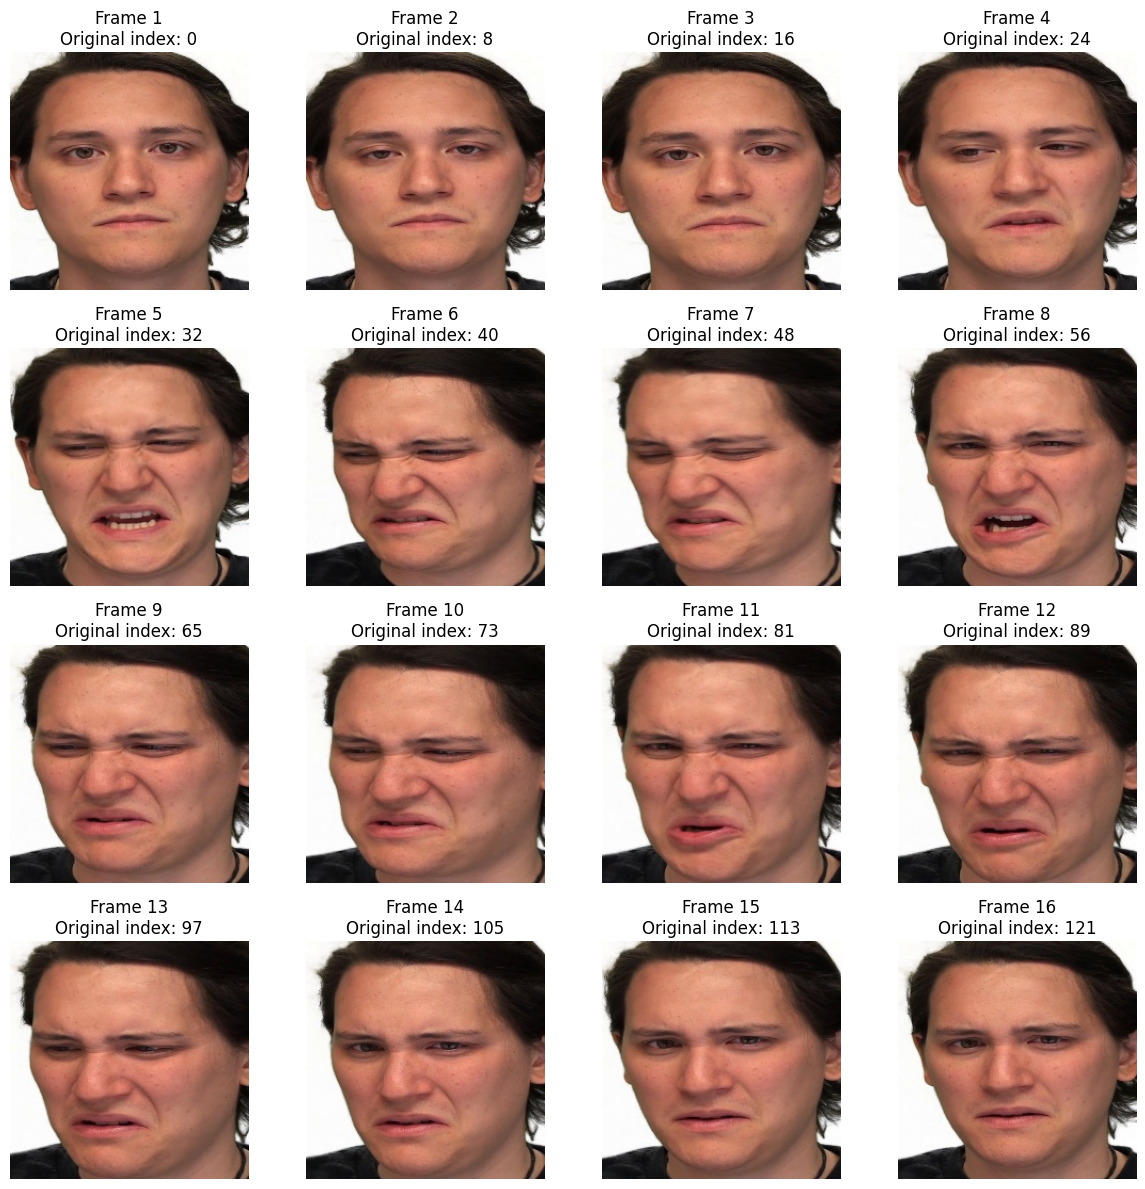

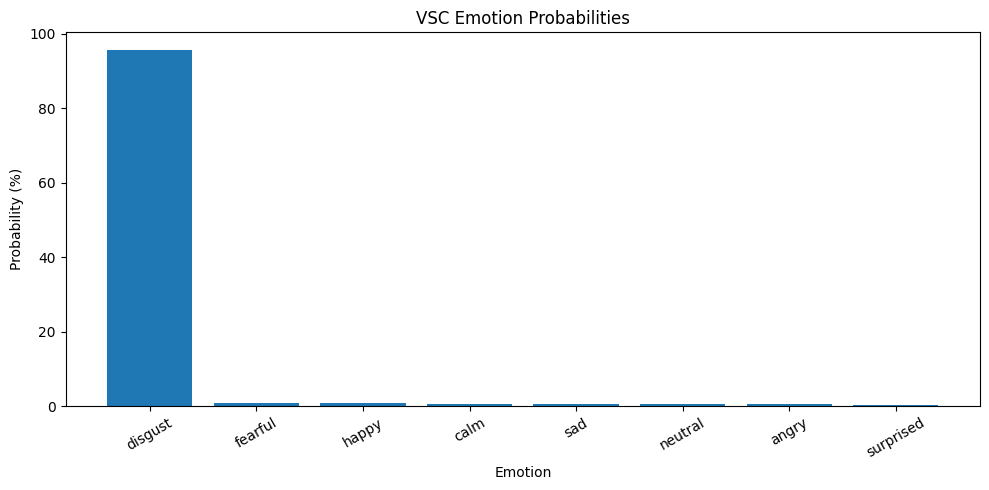

{'video_path': '/kaggle/input/datasets/orvile/ravdess-dataset/Video_Speech_Actor_23/Actor_23/01-01-07-02-01-01-23.mp4',
 'expected_emotion': 'disgust',
 'predicted_index': 6,
 'predicted_emotion': 'disgust',
 'confidence': 0.9557273387908936,
 'correct': True,
 'probabilities': {'neutral': 0.00516112195327878,
  'calm': 0.006808052770793438,
  'happy': 0.007847788743674755,
  'sad': 0.005882839672267437,
  'angry': 0.0049834889359772205,
  'fearful': 0.010106812231242657,
  'disgust': 0.9557273387908936,
  'surprised': 0.003482587868347764},
 'total_frames': 122,
 'selected_indices': [0,
  8,
  16,
  24,
  32,
  40,
  48,
  56,
  65,
  73,
  81,
  89,
  97,
  105,
  113,
  121],
 'faces_detected': 16,
 'input_shape': (1, 16, 3, 224, 224),
 'debug_directory': '/kaggle/working/vsc_single_video_frames'}

In [13]:
result = predict_single_video(
    video_path=VIDEO_PATH,
    show_faces=True,
    show_chart=True,
)

result

## 9) اختبار مجلد فيديوهات كامل — اختياري

ضع مسار المجلد الذي يحتوي على ملفات MP4.  
سيتم حفظ النتائج في:

`/kaggle/working/vsc_batch_predictions.csv`


In [14]:
def predict_video_folder(
    folder_path: str,
    output_csv: str = "/kaggle/working/vsc_batch_predictions.csv",
    recursive: bool = True,
) -> pd.DataFrame:
    folder = Path(folder_path)

    if not folder.is_dir():
        raise NotADirectoryError(
            f"المجلد غير موجود:\n{folder_path}"
        )

    pattern = "**/*.mp4" if recursive else "*.mp4"
    video_paths = sorted(folder.glob(pattern))

    if not video_paths:
        raise RuntimeError(
            "لم يتم العثور على ملفات MP4."
        )

    records = []

    for index, video_path in enumerate(
        video_paths,
        start=1,
    ):
        print(
            f"[{index}/{len(video_paths)}] "
            f"{video_path.name}"
        )

        try:
            prediction = predict_single_video(
                video_path=str(video_path),
                show_faces=False,
                show_chart=False,
                verbose=False,
            )

            record = {
                "video_path": str(video_path),
                "video_name": video_path.name,
                "expected_emotion": prediction[
                    "expected_emotion"
                ],
                "predicted_emotion": prediction[
                    "predicted_emotion"
                ],
                "confidence": prediction[
                    "confidence"
                ],
                "correct": prediction["correct"],
                "faces_detected": prediction[
                    "faces_detected"
                ],
            }

            for emotion, probability in prediction[
                "probabilities"
            ].items():
                record[f"prob_{emotion}"] = probability

            records.append(record)

        except Exception as error:
            records.append({
                "video_path": str(video_path),
                "video_name": video_path.name,
                "error": str(error),
            })

    dataframe = pd.DataFrame(records)
    dataframe.to_csv(
        output_csv,
        index=False,
    )

    print("\n✅ تم حفظ النتائج في:")
    print(output_csv)

    return dataframe


# مثال:
# FOLDER_PATH = "/kaggle/input/your-dataset/videos"
# batch_results = predict_video_folder(FOLDER_PATH)
# batch_results.head()

## 10) حفظ نتيجة الفيديو الفردي في JSON — اختياري

In [15]:
def save_single_result(
    result: dict,
    output_path: str = "/kaggle/working/vsc_single_prediction.json",
) -> str:
    serializable = dict(result)

    if isinstance(
        serializable.get("input_shape"),
        tuple,
    ):
        serializable["input_shape"] = list(
            serializable["input_shape"]
        )

    with open(
        output_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            serializable,
            file,
            indent=4,
            ensure_ascii=False,
        )

    print("✅ Saved:", output_path)

    return output_path


# save_single_result(result)

## ملاحظات مهمة

- لا تغيّر ترتيب `MODEL_CLASSES`.
- لا تستخدم Pipeline موديل Epoch 10 مع هذا الموديل.
- يجب أن يكون Tensor الإدخال بالشكل:

```text
[Batch, Frames, Channels, Height, Width]
[1, 16, 3, 224, 224]
```

- عند تشغيل فيديو RAVDESS، تستخرج النوت بوك التصنيف المتوقع تلقائيًا من اسم الملف.
- نتيجة `73.24%` تخص تقييم Test Split كامل، وليست ضمانًا لنجاح كل فيديو منفرد.
- فئة `surprised` كانت أضعف فئة في تقرير الاختبار الأصلي.


# الجزء البصري النهائي: التحليل الزمني والثقة السلوكية البصرية

هذا القسم يضيف المراحل التالية فوق موديل تصنيف المشاعر:

```text
Emotion probabilities لكل نافذة زمنية
        ↓
Emotion stability + Fear persistence + Calm recovery
        ↓
Visual Behavioral Confidence Score
```

## تنبيه منهجي

النتيجة تقيس **مؤشرات الثقة السلوكية الظاهرة أثناء الفيديو**، ولا تحكم على شخصية المرشح أو ثقته الداخلية بنفسه.

الأوزان والحدود المستخدمة هنا **Baseline تجريبية** تصلح لبناء النظام واختباره، ويجب معايرتها لاحقًا باستخدام فيديوهات مقابلات عليها تقييم بشري.


## 11) إعدادات التحليل الزمني

- `window_seconds`: طول كل نافذة زمنية.
- `stride_seconds`: المسافة بين بداية كل نافذتين.
- الإعداد الافتراضي `4/4` يعني نوافذ غير متداخلة، وهو أسرع.
- يمكن استخدام `4/2` لتحليل أدق مع تداخل 50%، لكنه أبطأ.


In [16]:
from dataclasses import asdict


@dataclass
class VisualConfidenceConfig:
    # تقسيم الفيديو
    window_seconds: float = 4.0
    stride_seconds: float = 4.0
    minimum_last_window_seconds: float = 1.5

    # Negative Affect = مجموع (Sad + Disgust + Fearful + Angry)
    # الأوزان دلوقتي "معاملات شدة" (severity multipliers)، مش نسب
    # لازم تجمع 1.0. الافتراضي 1.0 لكل واحدة = جمع خام بدون تخفيف،
    # لأن الاحتمالات دي أصلاً metrics متنافسة (مجموع الـ8 classes = 1.0).
    # زوّد وزن مشاعر معينة فوق 1.0 لو عايزها تاخد اهتمام أكبر في الـ severity.
    negative_affect_threshold: float = 0.25
    sad_weight: float = 1.0
    disgust_weight: float = 1.0
    fearful_weight: float = 1.0
    angry_weight: float = 1.0

    # Calm recovery (التعافي من حلقات الـ Negative Affect)
    recovery_horizon_windows: int = 2
    recovery_minimum_signal: float = 0.40
    recovery_minimum_gain: float = 0.10

    # موثوقية القياس
    minimum_windows_for_decision: int = 3
    minimum_face_detection_ratio: float = 0.60

    # Comfort Signal = مجموع (Calm + Neutral + Happy)
    # نفس المنطق: الافتراضي 1.0 لكل واحدة = جمع خام بدون تخفيف.
    calm_weight: float = 1.0
    neutral_weight: float = 1.0
    happy_weight: float = 1.0

    # أوزان الـ base score (4 مكونات، لازم تجمع 1.0 -- دي طبقة مختلفة
    # عن أوزان المشاعر فوق، مش نفس المشكلة، لأن كل مكون هنا 0-1 أصلاً)
    comfort_weight: float = 0.35
    stability_weight: float = 0.25
    recovery_weight: float = 0.20
    negative_affect_weight: float = 0.20

    # Confidence Interval
    confidence_interval_max_margin: float = 15.0

    def validate(self) -> None:
        if self.window_seconds <= 0:
            raise ValueError("window_seconds must be positive.")

        if self.stride_seconds <= 0:
            raise ValueError("stride_seconds must be positive.")

        comfort_weights = [
            self.calm_weight,
            self.neutral_weight,
            self.happy_weight,
        ]

        if any(w < 0 for w in comfort_weights):
            raise ValueError(
                "calm_weight, neutral_weight, happy_weight "
                "must be non-negative."
            )

        negative_weights = [
            self.sad_weight,
            self.disgust_weight,
            self.fearful_weight,
            self.angry_weight,
        ]

        if any(w < 0 for w in negative_weights):
            raise ValueError(
                "sad_weight, disgust_weight, fearful_weight, "
                "angry_weight must be non-negative."
            )

        base_weights = (
            self.comfort_weight
            + self.stability_weight
            + self.recovery_weight
            + self.negative_affect_weight
        )

        if abs(base_weights - 1.0) > 1e-6:
            raise ValueError(
                "comfort_weight + stability_weight + recovery_weight "
                "+ negative_affect_weight must sum to 1.0."
            )

        if self.confidence_interval_max_margin < 0:
            raise ValueError(
                "confidence_interval_max_margin must be non-negative."
            )


VISUAL_CFG = VisualConfidenceConfig()
VISUAL_CFG.validate()

print(json.dumps(
    asdict(VISUAL_CFG),
    indent=4,
    ensure_ascii=False,
))


{
    "window_seconds": 4.0,
    "stride_seconds": 4.0,
    "minimum_last_window_seconds": 1.5,
    "negative_affect_threshold": 0.25,
    "sad_weight": 1.0,
    "disgust_weight": 1.0,
    "fearful_weight": 1.0,
    "angry_weight": 1.0,
    "recovery_horizon_windows": 2,
    "recovery_minimum_signal": 0.4,
    "recovery_minimum_gain": 0.1,
    "minimum_windows_for_decision": 3,
    "minimum_face_detection_ratio": 0.6,
    "calm_weight": 1.0,
    "neutral_weight": 1.0,
    "happy_weight": 1.0,
    "comfort_weight": 0.35,
    "stability_weight": 0.25,
    "recovery_weight": 0.2,
    "negative_affect_weight": 0.2,
    "confidence_interval_max_margin": 15.0
}


## 12) بناء النوافذ الزمنية واستخراج فريمات كل نافذة

In [17]:
def get_video_information(
    video_path: str,
) -> Dict[str, float]:
    capture = cv2.VideoCapture(video_path)

    if not capture.isOpened():
        raise RuntimeError(
            f"تعذر فتح الفيديو:\n{video_path}"
        )

    fps = float(
        capture.get(cv2.CAP_PROP_FPS)
    )
    total_frames = int(
        capture.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    capture.release()

    if fps <= 0:
        raise RuntimeError(
            "تعذر قراءة FPS الخاص بالفيديو."
        )

    if total_frames <= 0:
        raise RuntimeError(
            "الفيديو لا يحتوي على فريمات."
        )

    duration_seconds = total_frames / fps

    return {
        "fps": fps,
        "total_frames": total_frames,
        "duration_seconds": duration_seconds,
    }


def build_temporal_windows(
    duration_seconds: float,
    window_seconds: float,
    stride_seconds: float,
    minimum_last_window_seconds: float,
) -> List[Tuple[float, float]]:
    if duration_seconds <= 0:
        return []

    # الفيديو القصير يعامل كنافذة واحدة.
    if duration_seconds <= window_seconds:
        return [(0.0, duration_seconds)]

    windows = []
    start_time = 0.0

    while start_time < duration_seconds:
        end_time = min(
            start_time + window_seconds,
            duration_seconds,
        )

        actual_length = end_time - start_time

        if actual_length >= minimum_last_window_seconds:
            windows.append(
                (start_time, end_time)
            )

        if end_time >= duration_seconds:
            break

        start_time += stride_seconds

    return windows


def read_window_frames(
    capture: cv2.VideoCapture,
    fps: float,
    total_frames: int,
    start_seconds: float,
    end_seconds: float,
    num_frames: int,
) -> Tuple[List[np.ndarray], List[int]]:
    start_frame = max(
        0,
        int(round(start_seconds * fps)),
    )

    end_frame = min(
        total_frames - 1,
        max(
            start_frame,
            int(round(end_seconds * fps)) - 1,
        ),
    )

    selected_indices = np.linspace(
        start_frame,
        end_frame,
        num_frames,
    ).round().astype(int)

    frames = []

    for frame_index in selected_indices:
        capture.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(frame_index),
        )

        success, bgr = capture.read()

        if not success:
            continue

        frames.append(
            cv2.cvtColor(
                bgr,
                cv2.COLOR_BGR2RGB,
            )
        )

    if not frames:
        raise RuntimeError(
            f"تعذر قراءة النافذة "
            f"{start_seconds:.2f}-{end_seconds:.2f} ثانية."
        )

    while len(frames) < num_frames:
        frames.append(
            frames[-1].copy()
        )

    return (
        frames[:num_frames],
        selected_indices.tolist(),
    )


def jpeg_roundtrip_to_pil(
    face_rgb: np.ndarray,
    quality: int = 95,
) -> Image.Image:
    face_rgb = np.ascontiguousarray(
        np.clip(
            face_rgb,
            0,
            255,
        ).astype(np.uint8)
    )

    face_bgr = cv2.cvtColor(
        face_rgb,
        cv2.COLOR_RGB2BGR,
    )

    success, encoded = cv2.imencode(
        ".jpg",
        face_bgr,
        [cv2.IMWRITE_JPEG_QUALITY, quality],
    )

    if not success:
        raise RuntimeError(
            "فشل ضغط الفريم بصيغة JPEG."
        )

    decoded_bgr = cv2.imdecode(
        encoded,
        cv2.IMREAD_COLOR,
    )

    if decoded_bgr is None:
        raise RuntimeError(
            "فشل فك ضغط الفريم."
        )

    decoded_rgb = cv2.cvtColor(
        decoded_bgr,
        cv2.COLOR_BGR2RGB,
    )

    return Image.fromarray(decoded_rgb)


def prepare_window_tensor(
    raw_frames: Sequence[np.ndarray],
    detector: MTCNN,
) -> Tuple[torch.Tensor, int]:
    frame_tensors = []
    faces_detected = 0

    for rgb_frame in raw_frames:
        face_rgb, detected = crop_largest_face(
            rgb=rgb_frame,
            detector=detector,
            image_size=CFG.image_size,
            margin_ratio=CFG.face_margin,
            minimum_probability=CFG.min_face_probability,
        )

        if detected:
            faces_detected += 1

        face_image = jpeg_roundtrip_to_pil(
            face_rgb,
            quality=95,
        )

        frame_tensors.append(
            IMAGE_TRANSFORM(face_image)
        )

    window_tensor = torch.stack(
        frame_tensors,
        dim=0,
    ).unsqueeze(0)

    window_tensor = window_tensor.to(
        device,
        dtype=torch.float32,
    )

    return window_tensor, faces_detected

## 13) استخراج احتمالات المشاعر لكل نافذة زمنية

In [18]:
@torch.inference_mode()
def analyze_emotion_windows(
    video_path: str,
    analysis_config: VisualConfidenceConfig = VISUAL_CFG,
    verbose: bool = True,
) -> pd.DataFrame:
    analysis_config.validate()

    if not os.path.isfile(video_path):
        raise FileNotFoundError(
            f"الفيديو غير موجود:\n{video_path}"
        )

    video_info = get_video_information(
        video_path
    )

    windows = build_temporal_windows(
        duration_seconds=video_info[
            "duration_seconds"
        ],
        window_seconds=analysis_config.window_seconds,
        stride_seconds=analysis_config.stride_seconds,
        minimum_last_window_seconds=(
            analysis_config.minimum_last_window_seconds
        ),
    )

    if not windows:
        raise RuntimeError(
            "لم يتم إنشاء نوافذ زمنية للفيديو."
        )

    detector = MTCNN(
        keep_all=True,
        min_face_size=40,
        post_process=False,
        device=device,
    )

    capture = cv2.VideoCapture(video_path)

    if not capture.isOpened():
        raise RuntimeError(
            f"تعذر فتح الفيديو:\n{video_path}"
        )

    records = []

    try:
        for window_index, (
            start_seconds,
            end_seconds,
        ) in enumerate(windows):
            raw_frames, frame_indices = (
                read_window_frames(
                    capture=capture,
                    fps=video_info["fps"],
                    total_frames=int(
                        video_info["total_frames"]
                    ),
                    start_seconds=start_seconds,
                    end_seconds=end_seconds,
                    num_frames=CFG.num_frames,
                )
            )

            window_tensor, faces_detected = (
                prepare_window_tensor(
                    raw_frames=raw_frames,
                    detector=detector,
                )
            )

            logits = model(window_tensor)

            probability_array = torch.softmax(
                logits,
                dim=1,
            )[0].float().cpu().numpy()

            predicted_index = int(
                probability_array.argmax()
            )

            record = {
                "window_index": window_index,
                "start_seconds": float(start_seconds),
                "end_seconds": float(end_seconds),
                "mid_seconds": float(
                    (start_seconds + end_seconds) / 2.0
                ),
                "duration_seconds": float(
                    end_seconds - start_seconds
                ),
                "dominant_emotion": classes[
                    predicted_index
                ],
                "model_top1_probability": float(
                    probability_array[predicted_index]
                ),
                "faces_detected": int(
                    faces_detected
                ),
                "face_detection_ratio": float(
                    faces_detected / CFG.num_frames
                ),
                "frame_indices": frame_indices,
            }

            for emotion, probability in zip(
                classes,
                probability_array,
            ):
                record[
                    f"prob_{emotion}"
                ] = float(probability)

            records.append(record)

            if verbose:
                print(
                    f"Window {window_index + 1:02d}/"
                    f"{len(windows):02d} | "
                    f"{start_seconds:6.2f}-"
                    f"{end_seconds:6.2f}s | "
                    f"{record['dominant_emotion']:<10} | "
                    f"{record['model_top1_probability'] * 100:6.2f}% | "
                    f"faces {faces_detected}/{CFG.num_frames}"
                )

    finally:
        capture.release()

    dataframe = pd.DataFrame(records)

    return dataframe

## 14) حساب المؤشرات الزمنية

### Emotion Stability

يستخدم متوسط المسافة بين توزيعات المشاعر المتتالية.
كلما كانت التوزيعات أقل تقلبًا، اقتربت النتيجة من `1`.

### Negative Affect Persistence

بدل الاعتماد على `fearful` بس، دلوقتي بيجمع 4 مشاعر سلبية مع بعض
(Sad + Disgust + Fearful + Angry) بأوزان قابلة للتعديل، ويحسب:

- متوسط احتمال الـ negative affect المجمّع.
- نسبة النوافذ التي تجاوز فيها الحد.
- أطول سلسلة متتالية من نوافذ الـ negative affect العالي.

### Calm Recovery

عند ظهور حلقة negative affect (بدل حلقة خوف بس)، يبحث النظام في النوافذ
التالية عن:

- انخفاض الـ negative affect المجمّع.
- ارتفاع إشارة `calm + 0.5 × neutral`.


In [19]:
def probability_matrix_from_windows(
    windows_df: pd.DataFrame,
) -> np.ndarray:
    columns = [
        f"prob_{emotion}"
        for emotion in classes
    ]

    return windows_df[
        columns
    ].to_numpy(dtype=np.float64)


def calculate_emotion_stability(
    windows_df: pd.DataFrame,
) -> Dict[str, float]:
    probability_matrix = (
        probability_matrix_from_windows(
            windows_df
        )
    )

    if len(probability_matrix) <= 1:
        return {
            "emotion_stability": 1.0,
            "mean_transition_distance": 0.0,
        }

    # Total Variation Distance بين 0 و1.
    transition_distances = (
        0.5
        * np.abs(
            probability_matrix[1:]
            - probability_matrix[:-1]
        ).sum(axis=1)
    )

    mean_transition_distance = float(
        transition_distances.mean()
    )

    stability = float(
        np.clip(
            1.0 - mean_transition_distance,
            0.0,
            1.0,
        )
    )

    return {
        "emotion_stability": stability,
        "mean_transition_distance": (
            mean_transition_distance
        ),
    }


def longest_true_streak(
    values: Sequence[bool],
) -> int:
    longest = 0
    current = 0

    for value in values:
        if bool(value):
            current += 1
            longest = max(longest, current)
        else:
            current = 0

    return longest


def negative_affect_probabilities_from_windows(
    windows_df: pd.DataFrame,
    sad_weight: float,
    disgust_weight: float,
    fearful_weight: float,
    angry_weight: float,
) -> np.ndarray:
    # جمع خام (مش متوسط) لأن الاحتمالات الأربعة دي جزء من توزيع
    # softmax واحد بيجمع 1.0 عبر كل الـ 8 classes. الأوزان هنا
    # معاملات شدة (severity multipliers) فوق الجمع الخام، مش نسب
    # مفروض تتساوى مجموعها 1.0 -- خلاف كده أي مشاعر منفردة قوية
    # (زي disgust 96%) هتتخفف بالغلط لمجرد إنها بتتقسم على 4.
    negative_affect = (
        sad_weight
        * windows_df["prob_sad"].to_numpy(
            dtype=np.float64
        )
        + disgust_weight
        * windows_df["prob_disgust"].to_numpy(
            dtype=np.float64
        )
        + fearful_weight
        * windows_df["prob_fearful"].to_numpy(
            dtype=np.float64
        )
        + angry_weight
        * windows_df["prob_angry"].to_numpy(
            dtype=np.float64
        )
    )

    # لو حد رفع وزن فوق 1.0 ممكن المجموع يعدي 1.0، فبنقصّه.
    return np.clip(negative_affect, 0.0, 1.0)


def calculate_negative_affect_persistence(
    windows_df: pd.DataFrame,
    threshold: float,
    sad_weight: float,
    disgust_weight: float,
    fearful_weight: float,
    angry_weight: float,
) -> Dict[str, float]:
    negative_affect_probabilities = (
        negative_affect_probabilities_from_windows(
            windows_df=windows_df,
            sad_weight=sad_weight,
            disgust_weight=disgust_weight,
            fearful_weight=fearful_weight,
            angry_weight=angry_weight,
        )
    )

    high_negative_affect_windows = (
        negative_affect_probabilities >= threshold
    )

    negative_affect_mean = float(
        negative_affect_probabilities.mean()
    )

    high_negative_affect_ratio = float(
        high_negative_affect_windows.mean()
    )

    longest_streak = longest_true_streak(
        high_negative_affect_windows
    )

    longest_streak_ratio = float(
        longest_streak
        / max(len(high_negative_affect_windows), 1)
    )

    negative_affect_persistence = float(
        np.clip(
            0.50 * negative_affect_mean
            + 0.25 * high_negative_affect_ratio
            + 0.25 * longest_streak_ratio,
            0.0,
            1.0,
        )
    )

    return {
        "negative_affect_persistence": (
            negative_affect_persistence
        ),
        "mean_negative_affect_probability": (
            negative_affect_mean
        ),
        "high_negative_affect_window_ratio": (
            high_negative_affect_ratio
        ),
        "longest_negative_affect_streak_windows": int(
            longest_streak
        ),
        "longest_negative_affect_streak_ratio": (
            longest_streak_ratio
        ),
    }


def negative_affect_episode_start_indices(
    negative_affect_probabilities: np.ndarray,
    threshold: float,
) -> List[int]:
    is_high = (
        negative_affect_probabilities >= threshold
    )

    starts = []

    for index, value in enumerate(is_high):
        previous = (
            bool(is_high[index - 1])
            if index > 0
            else False
        )

        if bool(value) and not previous:
            starts.append(index)

    return starts


def calculate_calm_recovery(
    windows_df: pd.DataFrame,
    negative_affect_threshold: float,
    sad_weight: float,
    disgust_weight: float,
    fearful_weight: float,
    angry_weight: float,
    recovery_horizon_windows: int,
    recovery_minimum_signal: float,
    recovery_minimum_gain: float,
) -> Dict[str, object]:
    negative_affect = (
        negative_affect_probabilities_from_windows(
            windows_df=windows_df,
            sad_weight=sad_weight,
            disgust_weight=disgust_weight,
            fearful_weight=fearful_weight,
            angry_weight=angry_weight,
        )
    )

    calm = windows_df[
        "prob_calm"
    ].to_numpy(dtype=np.float64)

    neutral = windows_df[
        "prob_neutral"
    ].to_numpy(dtype=np.float64)

    # Neutral يدخل بنصف وزن لأنه ليس هدوءًا صريحًا.
    calm_signal = calm + 0.5 * neutral

    episode_starts = (
        negative_affect_episode_start_indices(
            negative_affect_probabilities=(
                negative_affect
            ),
            threshold=negative_affect_threshold,
        )
    )

    # عدم وجود حلقة negative affect يعني أنه لم تكن هناك حاجة إلى التعافي.
    if not episode_starts:
        return {
            "calm_recovery": 1.0,
            "negative_affect_episode_count": 0,
            "recovered_episode_count": 0,
            "recovery_events": [],
            "recovery_note": (
                "No negative-affect episode required recovery."
            ),
        }

    recovery_events = []
    recovered_count = 0

    for start_index in episode_starts:
        future_start = start_index + 1
        future_end = min(
            len(windows_df),
            start_index
            + 1
            + recovery_horizon_windows,
        )

        recovered = False
        recovery_index = None

        if future_start < future_end:
            baseline_calm_signal = float(
                calm_signal[start_index]
            )
            starting_negative_affect = float(
                negative_affect[start_index]
            )

            for candidate_index in range(
                future_start,
                future_end,
            ):
                signal_gain = float(
                    calm_signal[candidate_index]
                    - baseline_calm_signal
                )

                candidate_recovered = (
                    calm_signal[candidate_index]
                    >= recovery_minimum_signal
                    and signal_gain
                    >= recovery_minimum_gain
                    and negative_affect[candidate_index]
                    < starting_negative_affect
                )

                if candidate_recovered:
                    recovered = True
                    recovery_index = candidate_index
                    recovered_count += 1
                    break

        recovery_events.append({
            "negative_affect_start_window": int(
                start_index
            ),
            "recovered": bool(recovered),
            "recovery_window": (
                int(recovery_index)
                if recovery_index is not None
                else None
            ),
        })

    recovery_score = float(
        recovered_count / len(episode_starts)
    )

    return {
        "calm_recovery": recovery_score,
        "negative_affect_episode_count": int(
            len(episode_starts)
        ),
        "recovered_episode_count": int(
            recovered_count
        ),
        "recovery_events": recovery_events,
        "recovery_note": None,
    }


## 15) حساب Visual Behavioral Confidence Score

### أ. Comfort Signal (جمع خام: calm + neutral + happy)

```
ComfortSignal = clip(
    calm_weight × ProbCalm
    + neutral_weight × ProbNeutral
    + happy_weight × ProbHappy,
    0, 1
)
```

الأوزان دي معاملات شدة افتراضها `1.0` لكل واحدة (يعني جمع خام
بدون تخفيف)، مش نسب لازم تجمع 1.0.

### ب. Negative Affect Persistence (جمع خام: sad + disgust + fearful + angry)

```
NegativeAffect = clip(
    sad_weight × ProbSad
    + disgust_weight × ProbDisgust
    + fearful_weight × ProbFearful
    + angry_weight × ProbAngry,
    0, 1
)
```

**ليه جمع مش متوسط؟** الاحتمالات دي كلها جزء من توزيع softmax واحد
(مجموع الـ 8 classes = 1.0 بالظبط). لو استخدمنا متوسط موزون بأوزان
تجمع 1.0، إشارة قوية زي "disgust 96%" هتتخفف تلقائيًا لمجرد إنها
بتتقسم على 4 مشاعر — حتى لو الباقيين قريبين من صفر. الجمع الخام
بيحافظ على "نسبة الاحتمال الكلية" اللي الموديل مديها لعائلة
المشاعر السلبية بالظبط.

يتحسب من `NegativeAffect` مؤشر `NegativeAffectPersistence` بنفس
منطق الـ Fear Persistence القديم (متوسط + نسبة النوافذ العالية +
أطول سلسلة).

### ج. Base Score (خطي بالكامل)

```
BaseScore = comfort_weight          × ComfortSignal
          + stability_weight        × EmotionStability
          + recovery_weight         × CalmRecovery
          + negative_affect_weight  × (1 - NegativeAffectPersistence)
```

هنا الأوزان (comfort/stability/recovery/negative_affect) طبقة
مختلفة تمامًا ولازم فعلاً تجمع 1.0، لأن كل مكون فيها أصلاً score
من 0 إلى 1 مش probability خام من توزيع واحد.

### د. Confidence Interval

```
ConfidenceMargin = (1 - VisualReliability) × confidence_interval_max_margin
ScoreRange = [FinalScore - Margin, FinalScore + Margin]
```

التصنيف:

- `High`: من 75 إلى 100.
- `Moderate`: من 50 إلى أقل من 75.
- `Low`: أقل من 50.
- `Insufficient evidence`: الفيديو قصير جدًا أو الوجه غير واضح بالقدر الكافي.


In [20]:
def calculate_comfort_signal(
    windows_df: pd.DataFrame,
    calm_weight: float,
    neutral_weight: float,
    happy_weight: float,
) -> Dict[str, float]:
    mean_calm = float(
        windows_df["prob_calm"].mean()
    )
    mean_neutral = float(
        windows_df["prob_neutral"].mean()
    )
    mean_happy = float(
        windows_df["prob_happy"].mean()
    )

    # جمع خام (مش متوسط موزون) لنفس سبب negative affect: دول جزء
    # من توزيع softmax واحد، فالجمع الخام = نسبة الاحتمال الكلية
    # اللي الموديل مديها لعائلة "الراحة/الارتياح".
    comfort = float(
        np.clip(
            calm_weight * mean_calm
            + neutral_weight * mean_neutral
            + happy_weight * mean_happy,
            0.0,
            1.0,
        )
    )

    return {
        "comfort_signal": comfort,
        "mean_calm_probability": mean_calm,
        "mean_neutral_probability": mean_neutral,
        "mean_happy_probability": mean_happy,
    }


def calculate_visual_reliability(
    windows_df: pd.DataFrame,
    minimum_windows: int,
) -> Dict[str, float]:
    face_detection_ratio = float(
        windows_df[
            "face_detection_ratio"
        ].mean()
    )

    window_coverage = float(
        min(
            len(windows_df)
            / max(minimum_windows, 1),
            1.0,
        )
    )

    reliability = float(
        np.clip(
            0.80 * face_detection_ratio
            + 0.20 * window_coverage,
            0.0,
            1.0,
        )
    )

    return {
        "visual_reliability": reliability,
        "mean_face_detection_ratio": (
            face_detection_ratio
        ),
        "window_coverage": window_coverage,
    }


def visual_confidence_level(
    score: float,
    sufficient_evidence: bool,
) -> str:
    if not sufficient_evidence:
        return "insufficient_evidence"

    if score >= 75.0:
        return "high"

    if score >= 50.0:
        return "moderate"

    return "low"


def calculate_visual_confidence_summary(
    windows_df: pd.DataFrame,
    analysis_config: VisualConfidenceConfig = VISUAL_CFG,
) -> Dict[str, object]:
    if windows_df.empty:
        raise ValueError(
            "windows_df is empty."
        )

    stability = calculate_emotion_stability(
        windows_df
    )

    negative_affect = (
        calculate_negative_affect_persistence(
            windows_df=windows_df,
            threshold=(
                analysis_config.negative_affect_threshold
            ),
            sad_weight=analysis_config.sad_weight,
            disgust_weight=(
                analysis_config.disgust_weight
            ),
            fearful_weight=(
                analysis_config.fearful_weight
            ),
            angry_weight=analysis_config.angry_weight,
        )
    )

    recovery = calculate_calm_recovery(
        windows_df=windows_df,
        negative_affect_threshold=(
            analysis_config.negative_affect_threshold
        ),
        sad_weight=analysis_config.sad_weight,
        disgust_weight=analysis_config.disgust_weight,
        fearful_weight=analysis_config.fearful_weight,
        angry_weight=analysis_config.angry_weight,
        recovery_horizon_windows=(
            analysis_config.recovery_horizon_windows
        ),
        recovery_minimum_signal=(
            analysis_config.recovery_minimum_signal
        ),
        recovery_minimum_gain=(
            analysis_config.recovery_minimum_gain
        ),
    )

    comfort = calculate_comfort_signal(
        windows_df=windows_df,
        calm_weight=analysis_config.calm_weight,
        neutral_weight=analysis_config.neutral_weight,
        happy_weight=analysis_config.happy_weight,
    )

    reliability = calculate_visual_reliability(
        windows_df=windows_df,
        minimum_windows=(
            analysis_config.minimum_windows_for_decision
        ),
    )

    # --- Base score (خطي بالكامل، من غير أي gated penalty) ---
    base_score_0_to_1 = (
        analysis_config.comfort_weight
        * comfort["comfort_signal"]
        + analysis_config.stability_weight
        * stability["emotion_stability"]
        + analysis_config.recovery_weight
        * recovery["calm_recovery"]
        + analysis_config.negative_affect_weight
        * (
            1.0
            - negative_affect[
                "negative_affect_persistence"
            ]
        )
    )

    visual_score = float(
        np.clip(
            base_score_0_to_1 * 100.0,
            0.0,
            100.0,
        )
    )

    # --- Confidence interval (مبني على visual reliability) ---
    confidence_margin = float(
        (1.0 - reliability["visual_reliability"])
        * analysis_config.confidence_interval_max_margin
    )

    score_low = float(
        np.clip(
            visual_score - confidence_margin,
            0.0,
            100.0,
        )
    )

    score_high = float(
        np.clip(
            visual_score + confidence_margin,
            0.0,
            100.0,
        )
    )

    enough_windows = (
        len(windows_df)
        >= analysis_config.minimum_windows_for_decision
    )

    enough_faces = (
        reliability["mean_face_detection_ratio"]
        >= analysis_config.minimum_face_detection_ratio
    )

    sufficient_evidence = bool(
        enough_windows and enough_faces
    )

    level = visual_confidence_level(
        score=visual_score,
        sufficient_evidence=sufficient_evidence,
    )

    summary = {
        "visual_behavioral_confidence_score": (
            visual_score
        ),
        "confidence_margin": confidence_margin,
        "score_range": {
            "low": score_low,
            "high": score_high,
        },
        "visual_confidence_level": level,
        "sufficient_evidence": sufficient_evidence,
        "number_of_windows": int(
            len(windows_df)
        ),
        "evidence_checks": {
            "enough_windows": bool(
                enough_windows
            ),
            "enough_faces": bool(
                enough_faces
            ),
        },
        "metrics": {
            **comfort,
            **stability,
            **negative_affect,
            **recovery,
            **reliability,
        },
        "formula_weights": {
            "comfort_signal": (
                analysis_config.comfort_weight
            ),
            "emotion_stability": (
                analysis_config.stability_weight
            ),
            "calm_recovery": (
                analysis_config.recovery_weight
            ),
            "low_negative_affect": (
                analysis_config.negative_affect_weight
            ),
        },
        "interpretation": (
            "Behavioral confidence indicators observed "
            "during this video; not a personality judgment. "
            "Score is reported as a range to reflect "
            "measurement uncertainty from visual reliability."
        ),
    }

    return summary


## 16) الرسوم الزمنية وحفظ النتائج

In [21]:
def plot_emotion_timeline(
    windows_df: pd.DataFrame,
) -> None:
    time_axis = windows_df[
        "mid_seconds"
    ].to_numpy()

    plt.figure(figsize=(13, 6))

    for emotion in [
        "calm",
        "neutral",
        "fearful",
        "happy",
        "sad",
    ]:
        plt.plot(
            time_axis,
            windows_df[
                f"prob_{emotion}"
            ].to_numpy() * 100.0,
            marker="o",
            label=emotion,
        )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Emotion probability (%)")
    plt.title(
        "Emotion Probabilities Across Temporal Windows"
    )
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_visual_metrics(
    summary: Dict[str, object],
) -> None:
    metrics = summary["metrics"]

    names = [
        "Comfort",
        "Stability",
        "Low negative affect",
        "Calm recovery",
        "Reliability",
    ]

    values = [
        metrics["comfort_signal"] * 100.0,
        metrics["emotion_stability"] * 100.0,
        (
            1.0
            - metrics["negative_affect_persistence"]
        ) * 100.0,
        metrics["calm_recovery"] * 100.0,
        metrics["visual_reliability"] * 100.0,
    ]

    plt.figure(figsize=(10, 5))
    plt.bar(names, values)
    plt.ylabel("Score (%)")
    plt.title(
        "Visual Behavioral Confidence Components"
    )
    plt.ylim(0, 100)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def save_visual_analysis(
    windows_df: pd.DataFrame,
    summary: Dict[str, object],
    output_directory: str = (
        "/kaggle/working/"
        "vsc_visual_confidence_output"
    ),
) -> Dict[str, str]:
    output_path = Path(output_directory)

    output_path.mkdir(
        parents=True,
        exist_ok=True,
    )

    csv_path = (
        output_path
        / "emotion_windows.csv"
    )

    json_path = (
        output_path
        / "visual_confidence_summary.json"
    )

    windows_to_save = windows_df.copy()

    if "frame_indices" in windows_to_save.columns:
        windows_to_save[
            "frame_indices"
        ] = windows_to_save[
            "frame_indices"
        ].apply(json.dumps)

    windows_to_save.to_csv(
        csv_path,
        index=False,
    )

    with open(
        json_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            summary,
            file,
            indent=4,
            ensure_ascii=False,
        )

    print("✅ Window results:", csv_path)
    print("✅ Summary       :", json_path)

    return {
        "windows_csv": str(csv_path),
        "summary_json": str(json_path),
    }

## 17) الدالة النهائية للجزء البصري

هذه هي الدالة التي ستستخدمها بعد ذلك داخل Backend أو Fusion Engine.


In [22]:
def analyze_visual_confidence(
    video_path: str,
    analysis_config: VisualConfidenceConfig = VISUAL_CFG,
    show_plots: bool = True,
    save_outputs: bool = True,
) -> Dict[str, object]:
    print("=" * 76)
    print("VSC VISUAL TEMPORAL ANALYSIS")
    print("Video:", video_path)
    print("=" * 76)

    windows_df = analyze_emotion_windows(
        video_path=video_path,
        analysis_config=analysis_config,
        verbose=True,
    )

    summary = calculate_visual_confidence_summary(
        windows_df=windows_df,
        analysis_config=analysis_config,
    )

    print("\n" + "=" * 76)
    score_range = summary["score_range"]

    print(
        "Visual Behavioral Confidence Score:",
        f"{summary['visual_behavioral_confidence_score']:.2f}/100",
        f"(range: {score_range['low']:.1f} - {score_range['high']:.1f}, "
        f"margin: +/-{summary['confidence_margin']:.1f})",
    )
    print(
        "Level:",
        summary["visual_confidence_level"].upper(),
    )
    print(
        "Sufficient evidence:",
        summary["sufficient_evidence"],
    )
    print(
        "Number of windows:",
        summary["number_of_windows"],
    )
    print("-" * 76)

    metrics = summary["metrics"]

    print(
        "Comfort signal            :",
        f"{metrics['comfort_signal'] * 100:.2f}%",
    )
    print(
        "Emotion stability         :",
        f"{metrics['emotion_stability'] * 100:.2f}%",
    )
    print(
        "Negative affect persist.  :",
        f"{metrics['negative_affect_persistence'] * 100:.2f}%",
    )
    print(
        "Calm recovery             :",
        f"{metrics['calm_recovery'] * 100:.2f}%",
    )
    print(
        "Reliability               :",
        f"{metrics['visual_reliability'] * 100:.2f}%",
    )
    print("=" * 76)

    output_files = None

    if save_outputs:
        output_files = save_visual_analysis(
            windows_df=windows_df,
            summary=summary,
        )

    if show_plots:
        plot_emotion_timeline(
            windows_df
        )
        plot_visual_metrics(
            summary
        )

    return {
        "video_path": video_path,
        "windows": windows_df,
        "summary": summary,
        "output_files": output_files,
    }

## 18) التشغيل

بالنسبة لفيديوهات المقابلات، استخدم فيديو إجابة مدته عدة ثوانٍ أو أكثر.  
فيديو RAVDESS القصير قد ينتج نافذة واحدة فقط، وبالتالي يظهر:

`insufficient_evidence`

رغم أن تصنيف المشاعر نفسه يعمل بصورة طبيعية.


VSC VISUAL TEMPORAL ANALYSIS
Video: /kaggle/input/datasets/orvile/ravdess-dataset/Video_Speech_Actor_23/Actor_23/01-01-07-02-01-01-23.mp4
Window 01/01 |   0.00-  4.00s | disgust    |  96.05% | faces 16/16

Visual Behavioral Confidence Score: 25.85/100 (range: 23.8 - 27.8, margin: +/-2.0)
Level: INSUFFICIENT_EVIDENCE
Sufficient evidence: False
Number of windows: 1
----------------------------------------------------------------------------
Comfort signal            : 1.82%
Emotion stability         : 100.00%
Negative affect persist.  : 98.93%
Calm recovery             : 0.00%
Reliability               : 86.67%
✅ Window results: /kaggle/working/vsc_visual_confidence_output/emotion_windows.csv
✅ Summary       : /kaggle/working/vsc_visual_confidence_output/visual_confidence_summary.json


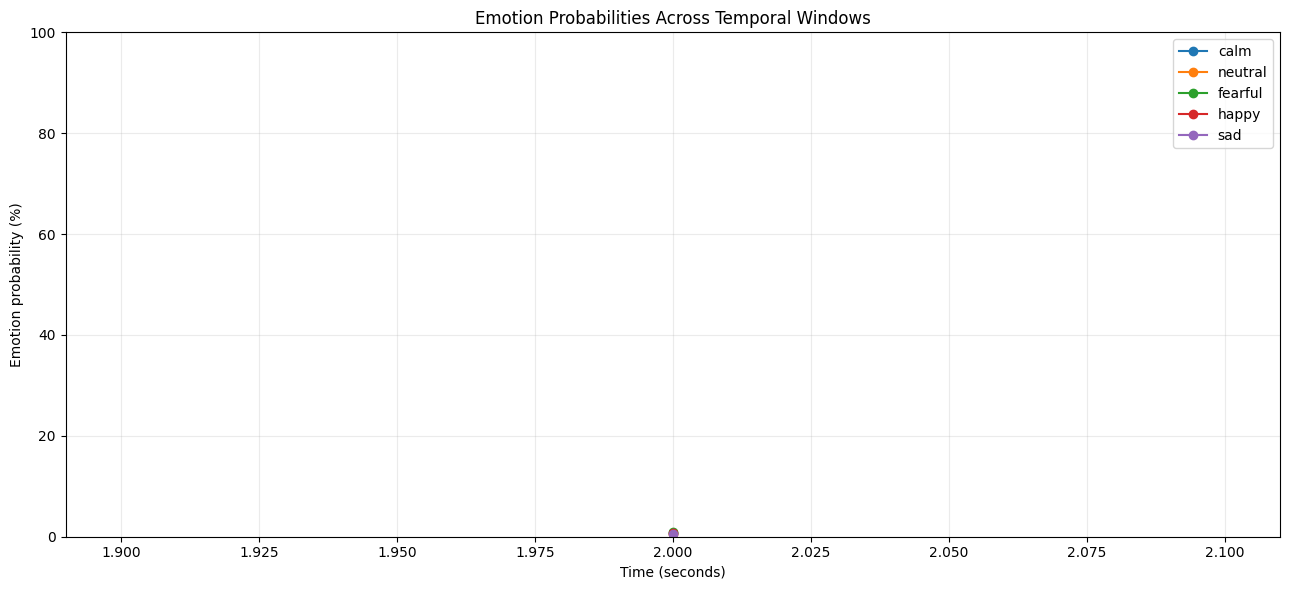

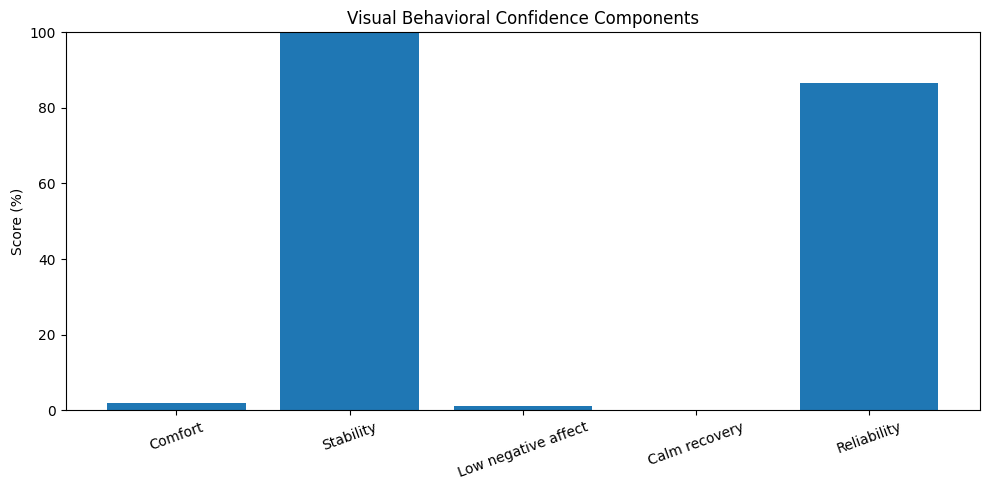

{'visual_behavioral_confidence_score': 25.849047943484038,
 'confidence_margin': 1.9999999999999996,
 'score_range': {'low': 23.849047943484038, 'high': 27.849047943484038},
 'visual_confidence_level': 'insufficient_evidence',
 'sufficient_evidence': False,
 'number_of_windows': 1,
 'evidence_checks': {'enough_windows': False, 'enough_faces': True},
 'metrics': {'comfort_signal': 0.018152281176298857,
  'mean_calm_probability': 0.006598569918423891,
  'mean_neutral_probability': 0.004584604874253273,
  'mean_happy_probability': 0.006969106383621693,
  'emotion_stability': 1.0,
  'mean_transition_distance': 0.0,
  'negative_affect_persistence': 0.9893140948843211,
  'mean_negative_affect_probability': 0.9786281897686422,
  'high_negative_affect_window_ratio': 1.0,
  'longest_negative_affect_streak_windows': 1,
  'longest_negative_affect_streak_ratio': 1.0,
  'calm_recovery': 0.0,
  'negative_affect_episode_count': 1,
  'recovered_episode_count': 0,
  'recovery_events': [{'negative_affec

In [23]:
visual_result = analyze_visual_confidence(
    video_path=VIDEO_PATH,
    analysis_config=VISUAL_CFG,
    show_plots=True,
    save_outputs=True,
)

visual_result["summary"]

## 17.1) تشغيل الجزء البصري على مجلد فيديوهات كامل (Batch)

بدل ما تشغّل `analyze_visual_confidence` على فيديو واحد بس، الخلية دي بتشغّله على **كل الفيديوهات** في مجلد كامل، وتحفظ النتائج (score, range, reliability, كل المؤشرات) في ملف CSV واحد.

مسار المجلد اللي هيتفحص:

`/kaggle/input/datasets/khaledexperiment/data-video`

النتائج هتتحفظ في:

`/kaggle/working/vsc_visual_confidence_batch.csv`


In [26]:
VIDEO_FOLDER_PATH = "/kaggle/input/datasets/khaledexperiment/data-video"


def run_visual_confidence_folder(
    folder_path: str = VIDEO_FOLDER_PATH,
    analysis_config: VisualConfidenceConfig = VISUAL_CFG,
    output_csv: str = "/kaggle/working/vsc_visual_confidence_batch.csv",
    recursive: bool = True,
) -> pd.DataFrame:
    folder = Path(folder_path)

    if not folder.is_dir():
        raise NotADirectoryError(
            f"المجلد غير موجود:\n{folder_path}"
        )

    pattern = "**/*.mp4" if recursive else "*.mp4"
    video_paths = sorted(folder.glob(pattern))

    if not video_paths:
        raise RuntimeError(
            "لم يتم العثور على ملفات MP4 في المجلد."
        )

    records = []

    for index, video_path in enumerate(
        video_paths,
        start=1,
    ):
        print(
            f"[{index}/{len(video_paths)}] "
            f"{video_path.name}"
        )

        try:
            result = analyze_visual_confidence(
                video_path=str(video_path),
                analysis_config=analysis_config,
                show_plots=False,
                save_outputs=False,
            )

            summary = result["summary"]
            metrics = summary["metrics"]
            score_range = summary["score_range"]

            records.append({
                "video_path": str(video_path),
                "video_name": video_path.name,
                "visual_behavioral_confidence_score": (
                    summary["visual_behavioral_confidence_score"]
                ),
                "score_range_low": score_range["low"],
                "score_range_high": score_range["high"],
                "confidence_margin": (
                    summary["confidence_margin"]
                ),
                "visual_confidence_level": (
                    summary["visual_confidence_level"]
                ),
                "sufficient_evidence": (
                    summary["sufficient_evidence"]
                ),
                "number_of_windows": (
                    summary["number_of_windows"]
                ),
                "comfort_signal": (
                    metrics["comfort_signal"]
                ),
                "emotion_stability": (
                    metrics["emotion_stability"]
                ),
                "negative_affect_persistence": (
                    metrics["negative_affect_persistence"]
                ),
                "calm_recovery": (
                    metrics["calm_recovery"]
                ),
                "visual_reliability": (
                    metrics["visual_reliability"]
                ),
            })

        except Exception as error:
            records.append({
                "video_path": str(video_path),
                "video_name": video_path.name,
                "error": str(error),
            })

    dataframe = pd.DataFrame(records)
    dataframe.to_csv(
        output_csv,
        index=False,
    )

    print("\n✅ تم حفظ نتائج الـ Batch في:")
    print(output_csv)

    return dataframe


# للتشغيل:
# batch_visual_results = run_visual_confidence_folder(VIDEO_FOLDER_PATH)
# batch_visual_results


In [27]:
# 1) شغّل دي الأول (شيل الـ #)
batch_visual_results = run_visual_confidence_folder(VIDEO_FOLDER_PATH)
batch_visual_results

# 2) بعد كده وبس بعد كده شغّل خلية الـ histogram

[1/4] ____.mp4
VSC VISUAL TEMPORAL ANALYSIS
Video: /kaggle/input/datasets/khaledexperiment/data-video/____.mp4
Window 01/03 |   0.00-  4.00s | happy      |  87.61% | faces 16/16
Window 02/03 |   4.00-  8.00s | happy      |  67.37% | faces 16/16
Window 03/03 |   8.00- 10.00s | happy      |  96.45% | faces 16/16

Visual Behavioral Confidence Score: 88.20/100 (range: 88.2 - 88.2, margin: +/-0.0)
Level: HIGH
Sufficient evidence: True
Number of windows: 3
----------------------------------------------------------------------------
Comfort signal            : 86.12%
Emotion stability         : 74.52%
Negative affect persist.  : 2.89%
Calm recovery             : 100.00%
Reliability               : 100.00%
[2/4] download (1).mp4
VSC VISUAL TEMPORAL ANALYSIS
Video: /kaggle/input/datasets/khaledexperiment/data-video/download (1).mp4
Window 01/03 |   0.00-  4.00s | neutral    |  86.60% | faces 16/16
Window 02/03 |   4.00-  8.00s | neutral    |  48.64% | faces 16/16
Window 03/03 |   8.00- 10.14s |

,video_path,video_name,visual_behavioral_confidence_score,score_range_low,score_range_high,confidence_margin,visual_confidence_level,sufficient_evidence,number_of_windows,comfort_signal,emotion_stability,negative_affect_persistence,calm_recovery,visual_reliability
0,/kaggle/input/datasets/khaledexperiment/data-v...,____.mp4,88.196271,88.196271,88.196271,0.0,high,True,3,0.861249,0.745213,0.028890,1.0,1.000000
1,/kaggle/input/datasets/khaledexperiment/data-v...,download (1).mp4,88.841699,88.841699,88.841699,0.0,high,True,3,0.984019,0.581163,0.006402,1.0,1.000000
2,/kaggle/input/datasets/khaledexperiment/data-v...,feelings.mp4,31.275042,31.275042,31.275042,0.0,low,True,3,0.355678,0.469183,0.645163,0.0,1.000000
3,/kaggle/input/datasets/khaledexperiment/data-v...,sample.mp4,98.804564,96.804564,100.000000,2.0,insufficient_evidence,False,1,0.972511,1.000000,0.011666,1.0,0.866667


## 17.2) توزيع الـ Scores عبر كل الفيديوهات (Histogram + Boxplot)

الخلية دي بترسم توزيع `visual_behavioral_confidence_score` على كل فيديوهات الـ batch:

- **Histogram**: يوريك شكل التوزيع العام (هل الأغلبية عالية؟ منخفضة؟ متجمعة في نص واحد؟)
- **Boxplot**: يوريك الـ median والـ outliers بسرعة (فيديوهات شاذة عن الباقي)

لازم تشغّل `run_visual_confidence_folder` الأول عشان `batch_visual_results` يكون موجود.


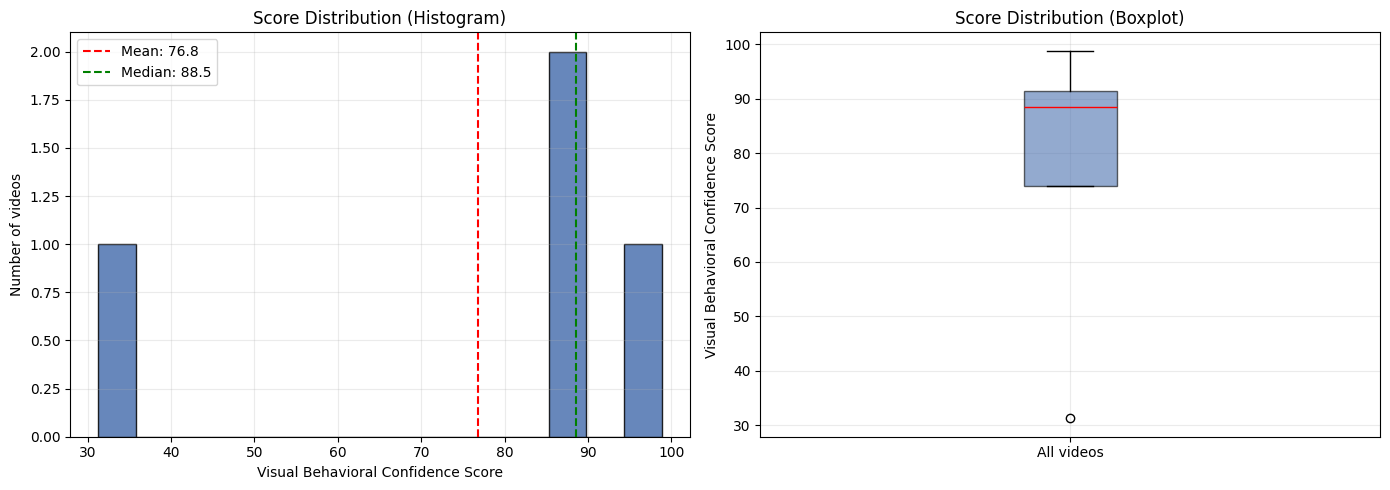

عدد الفيديوهات المُحلَّلة: 4
Mean  : 76.78
Median: 88.52
Std   : 30.72
Min   : 31.28
Max   : 98.8


In [28]:
if "batch_visual_results" not in globals():
    raise NameError(
        "متغير batch_visual_results مش موجود.\n"
        "لازم تشغّل الخلية اللي فيها:\n"
        "    batch_visual_results = run_visual_confidence_folder(VIDEO_FOLDER_PATH)\n"
        "الأول (شيل الـ # اللي قبلها وشغّلها)، وبعدين ارجع شغّل الخلية دي."
    )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

scores = batch_visual_results[
    "visual_behavioral_confidence_score"
].dropna()

# --- Histogram ---
axes[0].hist(
    scores,
    bins=15,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.85,
)
axes[0].axvline(
    scores.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {scores.mean():.1f}",
)
axes[0].axvline(
    scores.median(),
    color="green",
    linestyle="--",
    label=f"Median: {scores.median():.1f}",
)
axes[0].set_xlabel(
    "Visual Behavioral Confidence Score"
)
axes[0].set_ylabel("Number of videos")
axes[0].set_title(
    "Score Distribution (Histogram)"
)
axes[0].legend()
axes[0].grid(True, alpha=0.25)

# --- Boxplot ---
axes[1].boxplot(
    scores,
    vert=True,
    patch_artist=True,
    boxprops=dict(
        facecolor="#4C72B0",
        alpha=0.6,
    ),
    medianprops=dict(color="red"),
)
axes[1].set_ylabel(
    "Visual Behavioral Confidence Score"
)
axes[1].set_title(
    "Score Distribution (Boxplot)"
)
axes[1].set_xticklabels(
    ["All videos"]
)
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print(
    "عدد الفيديوهات المُحلَّلة:",
    len(scores),
)
print(
    "Mean  :", round(scores.mean(), 2),
)
print(
    "Median:", round(scores.median(), 2),
)
print(
    "Std   :", round(scores.std(), 2),
)
print(
    "Min   :", round(scores.min(), 2),
)
print(
    "Max   :", round(scores.max(), 2),
)


## 19) إعداد أدق أو أسرع

### أسرع — مناسب للتجارب الطويلة

```python
VISUAL_CFG.window_seconds = 4.0
VISUAL_CFG.stride_seconds = 4.0
```

### أدق — تداخل 50%

```python
VISUAL_CFG.window_seconds = 4.0
VISUAL_CFG.stride_seconds = 2.0
```

بعد تغيير الإعدادات:

```python
VISUAL_CFG.validate()
visual_result = analyze_visual_confidence(VIDEO_PATH)
```


## 20) شكل الخرج المناسب للـFusion Engine

الجزء المهم الذي يرسل إلى الـBackend:

```python
fusion_payload = {
    "visual_confidence_score": visual_result[
        "summary"
    ]["visual_behavioral_confidence_score"],

    "score_range": visual_result[
        "summary"
    ]["score_range"],

    "confidence_margin": visual_result[
        "summary"
    ]["confidence_margin"],

    "visual_confidence_level": visual_result[
        "summary"
    ]["visual_confidence_level"],

    "visual_reliability": visual_result[
        "summary"
    ]["metrics"]["visual_reliability"],

    "comfort_signal": visual_result[
        "summary"
    ]["metrics"]["comfort_signal"],

    "emotion_stability": visual_result[
        "summary"
    ]["metrics"]["emotion_stability"],

    "negative_affect_persistence": visual_result[
        "summary"
    ]["metrics"]["negative_affect_persistence"],

    "calm_recovery": visual_result[
        "summary"
    ]["metrics"]["calm_recovery"],
}
```

لا ترسل `visual_confidence_score` وحده؛ يجب إرسال `visual_reliability` و
`score_range` معه، عشان الـ Fusion Engine يقدر يعرف حجم عدم اليقين.
